# Untreated CoCulture Math Modelling (Simplified)

This notebook is a clean, standalone version for untreated coculture fitting.

Fixed monoculture baselines used:
- Naive/non_cis: Logistic with `r = 0.8725`, `K = 3947.9117`, `v = 1.0`
- Resistant/cis: Theta-logistic with `r = 0.4286`, `K = 3798.7457`, `v = 5.0`

The notebook fits only interaction terms for two coculture models:
1. Competitive interaction model (`alpha_SR`, `alpha_RS`)
2. Shared carrying capacity model (`K_shared`)

In [74]:
import Pkg

const NOTEBOOK_ENV = joinpath(pwd(), ".julia_env")
if isdir(NOTEBOOK_ENV)
    Pkg.activate(NOTEBOOK_ENV)
else
    println("Warning: notebook env not found at " * NOTEBOOK_ENV)
    println("Using current active env: " * Base.active_project())
end

const REQUIRED_PKGS = [
    "CSV",
    "DataFrames",
    "Statistics",
    "Optim",
    "Plots",
    "SciMLBase",
    "OrdinaryDiffEq",
]

function try_import(pkg::String)
    try
        Base.eval(Main, :(import $(Symbol(pkg))))
        println("Loaded: " * pkg)
        return true
    catch e
        println("Failed to load " * pkg * ": " * sprint(showerror, e))
        return false
    end
end

loaded = Dict{String,Bool}()
for pkg in REQUIRED_PKGS
    loaded[pkg] = try_import(pkg)
end

missing_pkgs = [p for p in REQUIRED_PKGS if !loaded[p]]
if !isempty(missing_pkgs)
    println("\nMissing packages: " * join(missing_pkgs, ", "))
    println("Run this once in a Julia REPL:")
    println("using Pkg; Pkg.activate(raw\"" * NOTEBOOK_ENV * "\"); Pkg.add(" * repr(missing_pkgs) * ")")
end

if get(loaded, "Plots", false)
    default(linewidth = 2, legend = :topright, framestyle = :box)
end

println("Active Julia env: " * Base.active_project())

In [75]:
# Paths + file discovery
project_root = dirname(dirname(pwd()))
coculture_root = joinpath(project_root, "Processed_Datasets", "Untreated CoCulture")
seeding_levels = ("20k", "30k")
roots = [joinpath(coculture_root, s) for s in seeding_levels]

@assert isdir(project_root) "project_root missing: $project_root"
@assert isdir(coculture_root) "coculture_root missing: $coculture_root"

function collect_day_average_files(roots::Vector{String})
    files = String[]
    for r in roots
        isdir(r) || continue
        for (root, _, filelist) in walkdir(r)
            for f in filelist
                endswith(f, "day_averages.csv") || continue
                push!(files, joinpath(root, f))
            end
        end
    end
    return sort(files)
end

all_day_average_files = collect_day_average_files(roots)
@assert !isempty(all_day_average_files) "No day-average files found."
println("Found $(length(all_day_average_files)) day-average files")

In [76]:
# Data loading (self-contained + rerun-safe)
using CSV, DataFrames

@assert @isdefined(all_day_average_files) "Run Cell 3 first to define all_day_average_files"

if !@isdefined(CoCultureDataset)
    struct CoCultureDataset
        density::String
        mix_label::String
        t::Vector{Float64}
        cis::Vector{Float64}
        non_cis::Vector{Float64}
    end
end

if !@isdefined(USE_WELL_LEVEL)
    const USE_WELL_LEVEL = false
end
if !@isdefined(DAY_SUFFIX)
    const DAY_SUFFIX = "_day_averages.csv"
end
if !@isdefined(WELL_DAY_SUFFIX)
    const WELL_DAY_SUFFIX = "_well_day_averages.csv"
end

function parse_density_compartment(path::AbstractString)
    parts = splitpath(path)
    idx = findfirst(==("Untreated CoCulture"), parts)
    idx === nothing && error("Could not find 'Untreated CoCulture' in path: $path")
    density = parts[idx + 1]
    compartment = parts[idx + 2]
    return density, compartment
end

function parse_mix_label(path::AbstractString)
    fname = splitpath(path)[end]
    m = match(r"measure_([0-9]+-[0-9]+)", fname)
    return m === nothing ? "unknown" : m.captures[1]
end

function detect_time_count_cols(df::DataFrame)
    names_df  = names(df)
    names_str = [lowercase(String(n)) for n in names_df]

    t_idx = findfirst(s -> s in ("day", "time"), names_str)
    t_idx === nothing && error("No time/day column found")

    if USE_WELL_LEVEL
        target_counts = ("mean_cells", "day_mean_cells", "avg_count")
    else
        target_counts = ("day_mean_cells", "mean_cells", "avg_count")
    end
    c_idx = findfirst(s -> s in target_counts, names_str)
    c_idx === nothing && error("No count column found")

    return names_df[t_idx], names_df[c_idx]
end

function load_single_compartment(file::String)
    df = CSV.read(file, DataFrame)
    tcol, ccol = detect_time_count_cols(df)
    t = Float64.(df[!, tcol])
    counts = Float64.(df[!, ccol])
    return t, counts
end

day0_total_baseline(density::String) = density == "20k" ? 67.0 : density == "30k" ? 100.0 : error("No day0 baseline for $density")

function mix_fraction(mix_label::String, compartment::String)
    parts = split(mix_label, '-')
    length(parts) == 2 || error("Unexpected mix format: $mix_label")
    a = parse(Float64, parts[1])
    b = parse(Float64, parts[2])
    tot = a + b
    compartment == "cis" && return a / tot
    compartment == "non_cis" && return b / tot
    error("Unknown compartment: $compartment")
end

function load_coculture_datasets(all_files::Vector{String})
    by_key = Dict{Tuple{String,String,String},String}()
    for f in all_files
        fname = splitpath(f)[end]
        if USE_WELL_LEVEL
            endswith(fname, WELL_DAY_SUFFIX) || continue
        else
            endswith(fname, DAY_SUFFIX) || continue
            occursin("_well_", fname) && continue
        end
        density, compartment = parse_density_compartment(f)
        mix = parse_mix_label(f)
        by_key[(density, compartment, mix)] = f
    end

    datasets = CoCultureDataset[]
    densities = sort(unique(k[1] for k in keys(by_key)))
    mixes     = sort(unique(k[3] for k in keys(by_key)))

    for density in densities, mix in mixes
        cis_key = (density, "cis", mix)
        non_key = (density, "non_cis", mix)
        haskey(by_key, cis_key) || continue
        haskey(by_key, non_key) || continue

        t_cis, cis_vals = load_single_compartment(by_key[cis_key])
        t_non, non_vals = load_single_compartment(by_key[non_key])
        @assert length(t_cis) == length(t_non)
        @assert all(t_cis .== t_non)

        total0 = day0_total_baseline(density)
        cis0 = mix_fraction(mix, "cis") * total0
        non0 = mix_fraction(mix, "non_cis") * total0

        t_full = vcat(0.0, t_cis)
        cis_full = vcat(cis0, cis_vals)
        non_full = vcat(non0, non_vals)

        push!(datasets, CoCultureDataset(density, mix, t_full, cis_full, non_full))
    end

    @assert !isempty(datasets) "No matched cis/non_cis datasets found"
    return datasets
end

datasets = load_coculture_datasets(all_day_average_files)
println("Loaded $(length(datasets)) matched datasets")
first(datasets)

CoCultureDataset("20k", "25-75", [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0], [16.75, 31.28, 54.13, 91.82, 189.74, 391.3, 609.7, 844.84, 1041.48, 1339.68, 1081.78, 1735.17, 986.34, 1465.85, 1085.67], [50.25, 12.81, 36.59, 105.56, 270.23, 849.87, 860.26, 1553.25, 1776.56, 1648.92, 2098.65, 2367.12, 2250.22, 2750.68, 2685.17])

In [77]:
# Models + fitting (self-contained + rerun-safe)
import Pkg
const NOTEBOOK_ENV = joinpath(pwd(), ".julia_env")
isdir(NOTEBOOK_ENV) && Pkg.activate(NOTEBOOK_ENV)

using Optim, DataFrames, Statistics, Random

@assert @isdefined(CoCultureDataset) "Run Cell 4 first to define CoCultureDataset and datasets"

try
    import SciMLBase
    import OrdinaryDiffEq
catch e
    error("SciMLBase/OrdinaryDiffEq are required for ODE simulation. Activate env: using Pkg; Pkg.activate(raw\"$(NOTEBOOK_ENV)\"). Then install if needed: Pkg.add([\"SciMLBase\",\"OrdinaryDiffEq\"]). Original error: $(sprint(showerror, e))")
end

if !@isdefined(CoCultureModel)
    abstract type CoCultureModel end
end

if !@isdefined(FIXED_MONO_BASELINES)
    const FIXED_MONO_BASELINES = Dict(
        :non_cis => (r = 0.8725, K = 3947.9117, v = 1.0),
        :cis     => (r = 0.4286, K = 3798.7457, v = 5.0),
    )
end

if !@isdefined(FixedMonoCompetitive)
    struct FixedMonoCompetitive <: CoCultureModel end
end
if !@isdefined(FixedMonoSharedK)
    struct FixedMonoSharedK <: CoCultureModel end
end

function rhs!(du, u, p, t, ::FixedMonoCompetitive)
    S, R = u
    alpha_SR, alpha_RS = p
    bS = FIXED_MONO_BASELINES[:non_cis]
    bR = FIXED_MONO_BASELINES[:cis]

    gS = max(0.0, 1 - (S + alpha_SR * R) / bS.K)
    gR = max(0.0, 1 - (alpha_RS * S + R) / bR.K)
    du[1] = bS.r * S * (gS^bS.v)
    du[2] = bR.r * R * (gR^bR.v)
    return nothing
end

function rhs!(du, u, p, t, ::FixedMonoSharedK)
    S, R = u
    K_shared = p[1]
    bS = FIXED_MONO_BASELINES[:non_cis]
    bR = FIXED_MONO_BASELINES[:cis]

    g = max(0.0, 1 - (S + R) / K_shared)
    du[1] = bS.r * S * (g^bS.v)
    du[2] = bR.r * R * (g^bR.v)
    return nothing
end

initial_guess(::FixedMonoCompetitive, ds::CoCultureDataset) = Float64[1.0, 1.0]
bounds(::FixedMonoCompetitive, ds::CoCultureDataset) = (Float64[0.0, 0.0], Float64[3.0, 3.0])

function initial_guess(::FixedMonoSharedK, ds::CoCultureDataset)
    return Float64[mean((FIXED_MONO_BASELINES[:non_cis].K, FIXED_MONO_BASELINES[:cis].K))]
end
bounds(::FixedMonoSharedK, ds::CoCultureDataset) = (Float64[500.0,], Float64[1.0e5,])

function simulate_model(model::CoCultureModel, ds::CoCultureDataset, p_vec::AbstractVector; solver_kwargs...)
    u0 = [ds.non_cis[1], ds.cis[1]]
    tspan = (first(ds.t), last(ds.t))
    f!(du, u, p, t) = rhs!(du, u, p, t, model)
    prob = SciMLBase.ODEProblem(f!, u0, tspan, collect(p_vec))
    sol = OrdinaryDiffEq.solve(prob, OrdinaryDiffEq.Tsit5(); saveat = ds.t, solver_kwargs...)
    return ds.t, Array(sol[1, :]), Array(sol[2, :])
end

function sse_log(model::CoCultureModel, p_vec::AbstractVector, ds::CoCultureDataset; eps::Float64 = 1.0)
    penalty = 1e12
    t = nothing; S = nothing; R = nothing
    try
        t, S, R = simulate_model(model, ds, p_vec; abstol = 1e-8, reltol = 1e-6)
    catch
        return penalty
    end

    if any(.!isfinite.(S)) || any(.!isfinite.(R)) || any(S .<= -eps) || any(R .<= -eps)
        return penalty
    end

    errS = log.(S .+ eps) .- log.(ds.non_cis .+ eps)
    errR = log.(R .+ eps) .- log.(ds.cis .+ eps)
    return sum(errS.^2 .+ errR.^2)
end

if !@isdefined(ModelSpec)
    struct ModelSpec
        name::String
        model::CoCultureModel
    end
end

if !@isdefined(MODEL_SPECS)
    const MODEL_SPECS = [
        ModelSpec("fixed_mono_competitive_log", FixedMonoCompetitive()),
        ModelSpec("fixed_mono_sharedK_log", FixedMonoSharedK())
    ]
end

function fit_model(spec::ModelSpec, ds::CoCultureDataset; n_starts::Int = 15)
    p0 = initial_guess(spec.model, ds)
    lb, ub = bounds(spec.model, ds)

    loss(p) = sse_log(spec.model, p, ds; eps = 1.0)

    seeds = Vector{Vector{Float64}}()
    push!(seeds, copy(p0))
    for _ in 1:(n_starts - 1)
        push!(seeds, lb .+ rand(length(lb)) .* (ub .- lb))
    end

    best_val = Inf
    best_p = copy(p0)
    best_conv = false

    for init in seeds
        res = Optim.optimize(loss, lb, ub, init,
            Optim.Fminbox(Optim.NelderMead()),
            Optim.Options(iterations = 800, show_trace = false))
        val = Optim.minimum(res)
        if val < best_val
            best_val = val
            best_p = collect(Optim.minimizer(res))
            best_conv = Optim.converged(res)
        end
    end

    n = 2 * length(ds.t)
    k = length(best_p)
    sigma2 = best_val / n
    aic = n * log(sigma2) + 2k
    bic = n * log(sigma2) + k * log(n)

    ptxt = "[" * join(round.(best_p, digits = 6), ", ") * "]"

    return (
        density = ds.density,
        mix = ds.mix_label,
        model = spec.name,
        params = ptxt,
        sse = best_val,
        aic = aic,
        bic = bic,
        converged = best_conv
    )
end

println("Simplified model setup ready. Active env: " * Base.active_project())

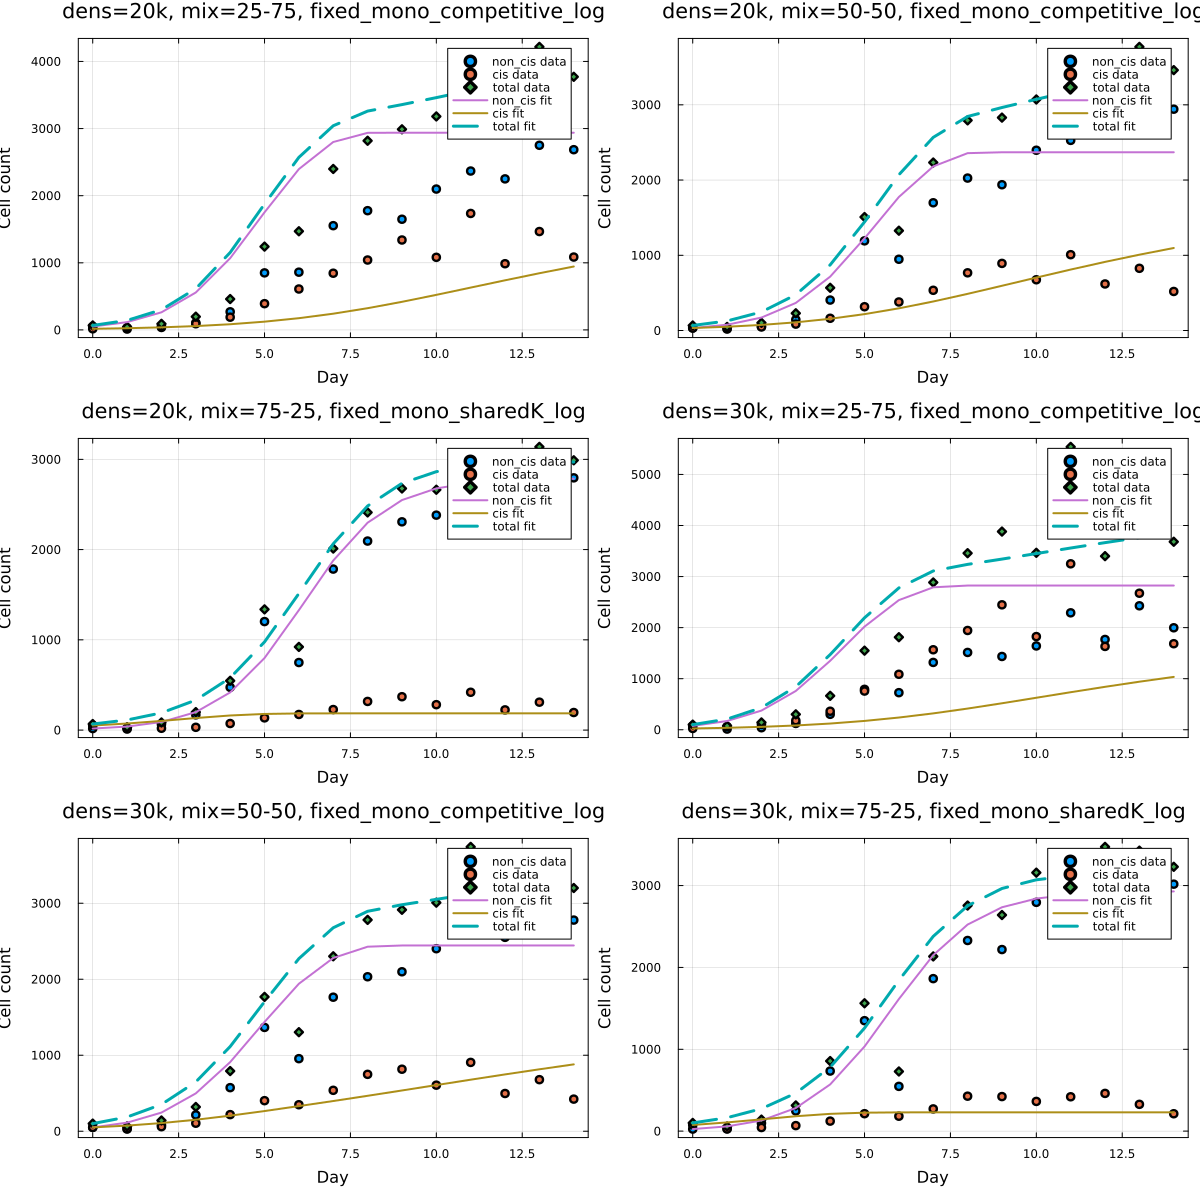

In [78]:
# Run fits + outputs + plots (formatted output style)
import Pkg
const NOTEBOOK_ENV = joinpath(pwd(), ".julia_env")
isdir(NOTEBOOK_ENV) && Pkg.activate(NOTEBOOK_ENV)

using CSV, DataFrames, Plots, Statistics, Optim

try
    import SciMLBase
    import OrdinaryDiffEq
catch e
    error("SciMLBase/OrdinaryDiffEq are required for simulation and plotting fits. Activate env: using Pkg; Pkg.activate(raw\"$(NOTEBOOK_ENV)\"). Then install if needed: Pkg.add([\"SciMLBase\",\"OrdinaryDiffEq\"]). Original error: $(sprint(showerror, e))")
end

@assert @isdefined(datasets) "Run Cell 4 first to define datasets"
@assert @isdefined(MODEL_SPECS) "Run Cell 5 first to define model specs"
@assert @isdefined(fit_model) "Run Cell 5 first to define fit_model"

rows = NamedTuple[]
for ds in datasets
    for spec in MODEL_SPECS
        push!(rows, fit_model(spec, ds))
    end
end

fit_df = DataFrame(rows)
sort!(fit_df, [:density, :mix, :bic])

println("\n=== Untreated CoCulture: Model Fits (sorted by BIC) ===")
show(fit_df, allrows = true, allcols = true)

out_csv = joinpath(pwd(), "untreated_coculture_simplified_fits.csv")
CSV.write(out_csv, fit_df)
println("\nSaved fit table: " * out_csv)

function parse_params(ptxt::AbstractString)
    x = replace(ptxt, "[" => "", "]" => "")
    isempty(strip(x)) && return Float64[]
    return parse.(Float64, split(x, ","))
end

function model_from_name(name::String)
    name == "fixed_mono_competitive_log" && return FixedMonoCompetitive()
    name == "fixed_mono_sharedK_log" && return FixedMonoSharedK()
    error("Unknown model: $name")
end

best_rows = combine(groupby(fit_df, [:density, :mix])) do g
    g[argmin(g.bic), :]
end
sort!(best_rows, [:density, :mix])

println("\n=== Best Model Per Condition (lowest BIC) ===")
show(best_rows, allrows = true, allcols = true)

bic_summary = combine(groupby(fit_df, :model),
    :bic => mean   => :bic_mean,
    :bic => median => :bic_median,
    :bic => minimum => :bic_min,
    :bic => maximum => :bic_max)
sort!(bic_summary, :bic_mean)

println("\n=== BIC Summary By Model ===")
show(bic_summary, allrows = true, allcols = true)

nplots = min(length(datasets), 6)
plt = plot(layout = (3, 2), size = (1200, 1200))

for i in 1:nplots
    ds = datasets[i]
    sub = fit_df[(fit_df.density .== ds.density) .& (fit_df.mix .== ds.mix_label), :]
    row = sub[argmin(sub.bic), :]
    model = model_from_name(row.model)
    p = parse_params(row.params)
    t, S, R = simulate_model(model, ds, p; abstol = 1e-8, reltol = 1e-6)

    total_data = ds.non_cis .+ ds.cis
    total_fit = S .+ R

    scatter!(plt[i], ds.t, ds.non_cis, label = "non_cis data")
    scatter!(plt[i], ds.t, ds.cis, label = "cis data")
    scatter!(plt[i], ds.t, total_data, label = "total data", markershape = :diamond, markersize = 4)
    plot!(plt[i], t, S, label = "non_cis fit")
    plot!(plt[i], t, R, label = "cis fit")
    plot!(plt[i], t, total_fit, label = "total fit", linewidth = 3, linestyle = :dash)
    title!(plt[i], "dens=$(ds.density), mix=$(ds.mix_label), $(row.model)")
    xlabel!(plt[i], "Day")
    ylabel!(plt[i], "Cell count")
end

plot_path = joinpath(pwd(), "untreated_coculture_simplified_bestfits.png")
savefig(plt, plot_path)
display(plt)
println("\nSaved best-fit plot grid: " * plot_path)
println("Active Julia env: " * Base.active_project())